# **생성 모델**

# 1. 생성 모델의 개념

## 1. 분류 모델 vs 생성 모델
- **생성 모델**: 주어진 학습 데이터를 학습해, 학습 데이터의 분포를 따르는 유사한 데이터를 생성하는 모델
    - 데이터 자체의 확률 분포 P(x)를 학습하여, 학습 데이터와 유사한 새로운 데이터를 만들어내는 모델
    - 학습 목표: P(X) 모델링 (세상에 존재할 법한 데이터 X 자체의 확률 분포 파악) 
- **분류 모델**: 입력된 데이터가 어떤 레이블에 속할지 결정하는 모델
    - 학습 목표: P(Y∣X) 모델링 (데이터 X가 주어졌을 때 정답 Y일 확률 계산)
<br>
## 2. 생성 모델의 분류
- 명시적 확률밀도 모델(Explicit density Models)
    - 모델이 데이터의 확률 분포인 P(X)의 값을 직접적으로 수치화하여 출력할 수 있는 모델
    - 정확히 계산 가능한 모델 (Tractable Density): 수학적으로 확률 값을 정확하게 계산할 수 있음
    - 근사적 밀도 모델 (Approximate Density): 확률의 근사값이나 하한선 계산
- 암시적 확률밀도 모델(Implicit density Models)
    - 데이터의 확률 분포 P(X)가 무엇인지 수치로 알려주지 않지만, 그 분포를 따르는 데이터를 생성(Sampling)할 수 있는 모델
    - 직접 샘플링 : 신경망을 한 번 통과시키는 것만으로 데이터를 바로 만들어냄
    - 간접/반복적 샘플링 (마르코브 체인) : 여러 단계를 거쳐 점진적으로 데이터를 완성

# 2. AE, VAE

## 1. AE
- Auto Encoder(AE): 
    - 입력과 동일한 출력을 만드는 것을 목적으로 하는 신경망
    - 차원 축소, 특징 추출, 노이즈 제거, 이상 탐지 등 데이터 복원이나 특성 학습에 사용
    - 일반적인 인코더/디코더와 달리 정답지가 없음
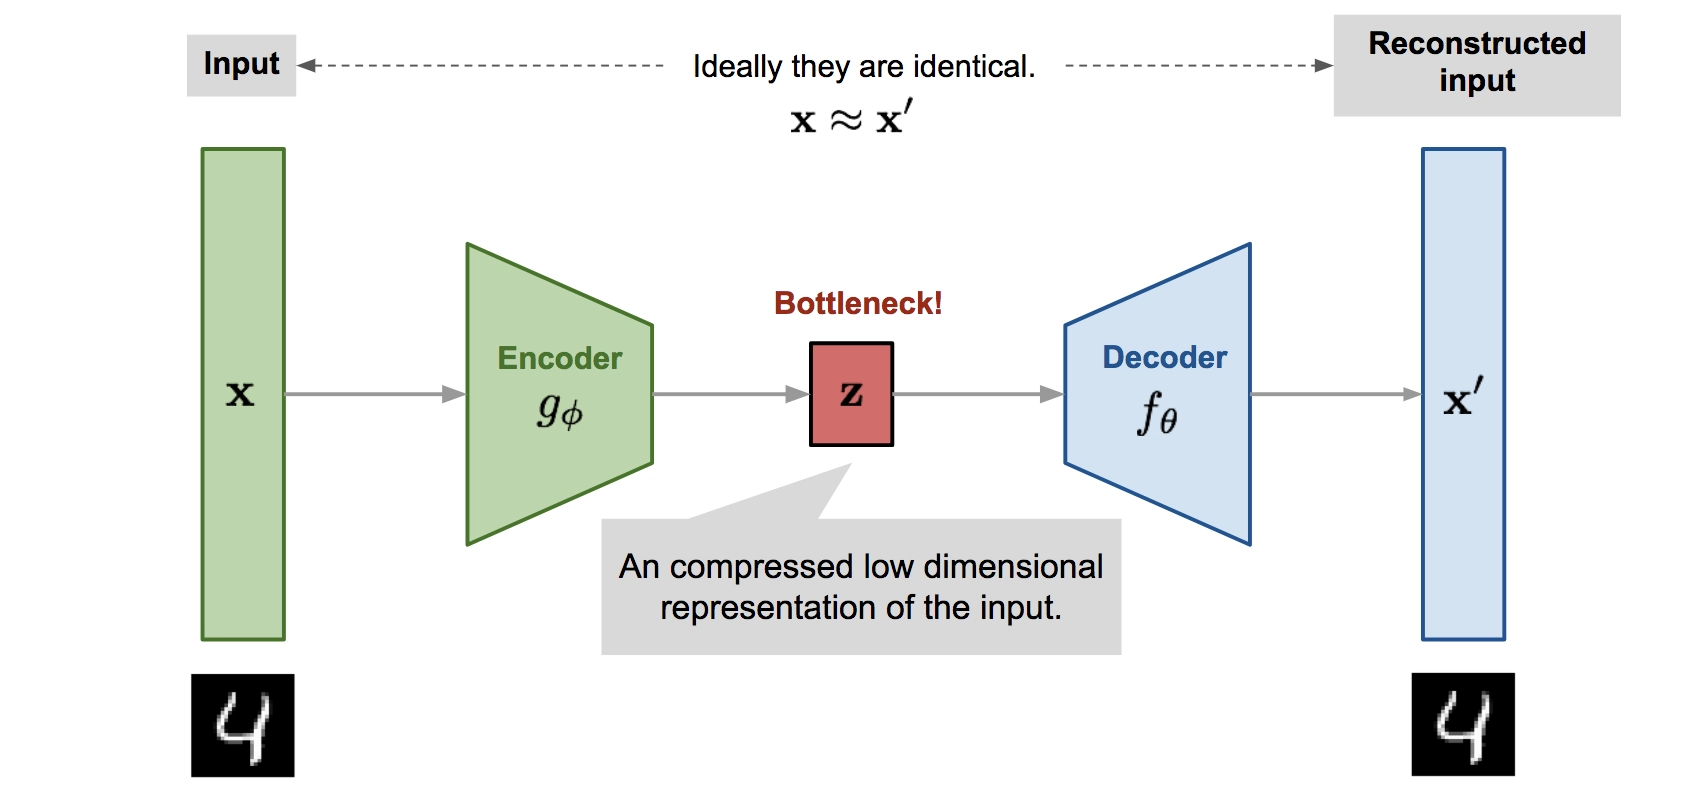  
- 작동과정:
    1. 압축 단계 (Encoder): 방대한 정보를 가진 입력 데이터를 잠재 벡터로 통과시키기 위해 핵심만 남기고 깎아냄
    2. 병목 통과 (Bottleneck): 가장 중요한 정보만 남은 상태
        - 잠재 벡터(Latent Vector): 학습 과정에서 겉으로 드러나지 않는 숨겨진 특징 정보(피처) 저장
    3. 복원 단계 (Decoder): 통과한 핵심 정보만을 단서로 삼아, 다시 원래의 커다란 이미지로 복원
    => 인코더로 들어가는 입력 데이터와 디코더가 출력한 데이터가 같아지도록 훈련하여 그 과정에서 데이터의 가장 중요한 특징(잠재 벡터)만 남김
<br>
## 2. VAE
- Variational Auto Encoder(VAE):  데이터의 잠재적인 구조를 학습하여, 원본과 닮았지만 새로운 데이터를 생성해내는 모델
    - AE와 달리 잠재 벡터를 점이 아닌 가우시안 분포(범위)로 학습

| 구분            | Auto Encoder (AE)                       | Variational Auto Encoder (VAE)            |
| ------------- | --------------------------------------- | ----------------------------------------- |
| 주인공           | 인코더<br>압축이 중요<br>디코더는 압축이 잘되었는지 검사하는 역할 | 디코더<br>생성이 중요<br>인코더는 디코더를 잘 학습시키기 위한 가이드 |
| 잠재 벡터 `z`의 형태 | 고정된 수치, 즉 Point                         | 확률 분포, 즉 Distribution                     |
| 잠재 공간의 특성     | 불연속적이고 비어있는 공간이 많음                      | 연속적이며 표준 정규 분포를 따름                        |
| 샘플링 결과        | 학습 데이터 외 구역에서는 복원이 불가능함                 | 어느 지점에서든 의미 있는 생성이 가능함                    |
| 주요 효과         | 데이터 압축 및 특징 추출                          | 데이터 생성 및 보간, Interpolation                |

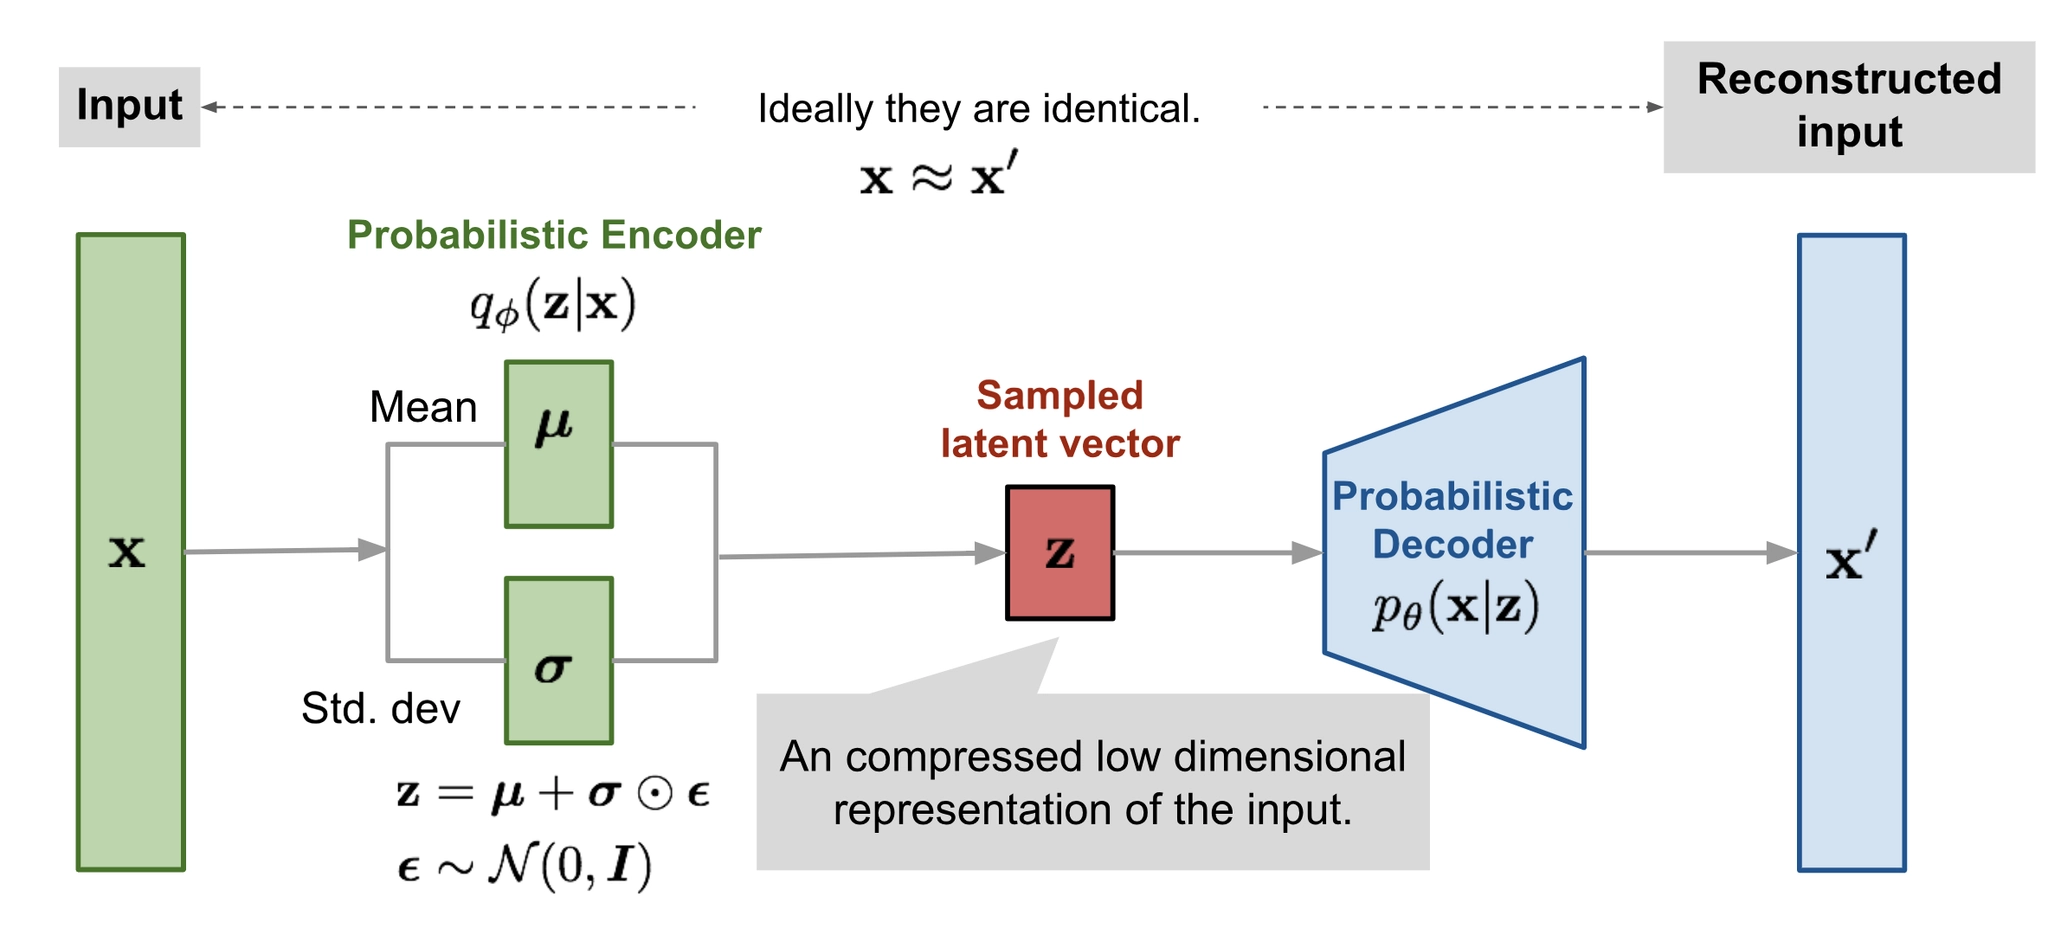  

- 작동과정: 
    1. 분포 예측 단계 (Encoder): 입력 데이터를 특정 점이 아닌, 데이터가 존재할 확률이 높은 '구역'으로 매핑
    2. 샘플링 및 재파라미터화 (Sampling & Reparameterization): 예측한 분포에서 실제 디코더에 전달할 잠재 벡터(𝑧)를 하나 뽑는 단계
    3. 생성 단계 (Decoder): 샘플링된 잠재 벡터(𝑧)를 단서로 사용하여 새로운 데이터를 생성
    => VAE는 잠재 공간이 표준 정규 분포라는 규칙을 따르도록 강제, 어떤 지점을 선택하더라도 디코더가 그럴듯한 의미를 가진 데이터를 생성해낼 수 있음

# 3. GAN

## 1. GAN의 개념
- GAN(Generative Adversarial Network): 생성자 신경망과 판별자 신경망이 서로 적대적으로 경쟁하면서, 훈련을 통하여 자신의 작업을 점점 더 정교하게 수행하는 신경망 모델
- GAN의 목적:  
    - 생성자(Generator): 진짜 분포에 가까운 가짜분포를 생성하는 것
    - 판별자(Discriminator): 표본이 가짜 분포에 속하는지 진짜 분포에 속하는지를 결정하는 것
    => **“실제 데이터의 분포”에 가까운 데이터를 생성하는 것**, 판별자가 진짜/가짜를 판단하지 못하는 경계를 최적 솔루션으로 간주
<br>
## 2. GAN의 구조
- 두 개의 신경망이 최소-최대 게임(MinMax Game)을 수행하는 구조
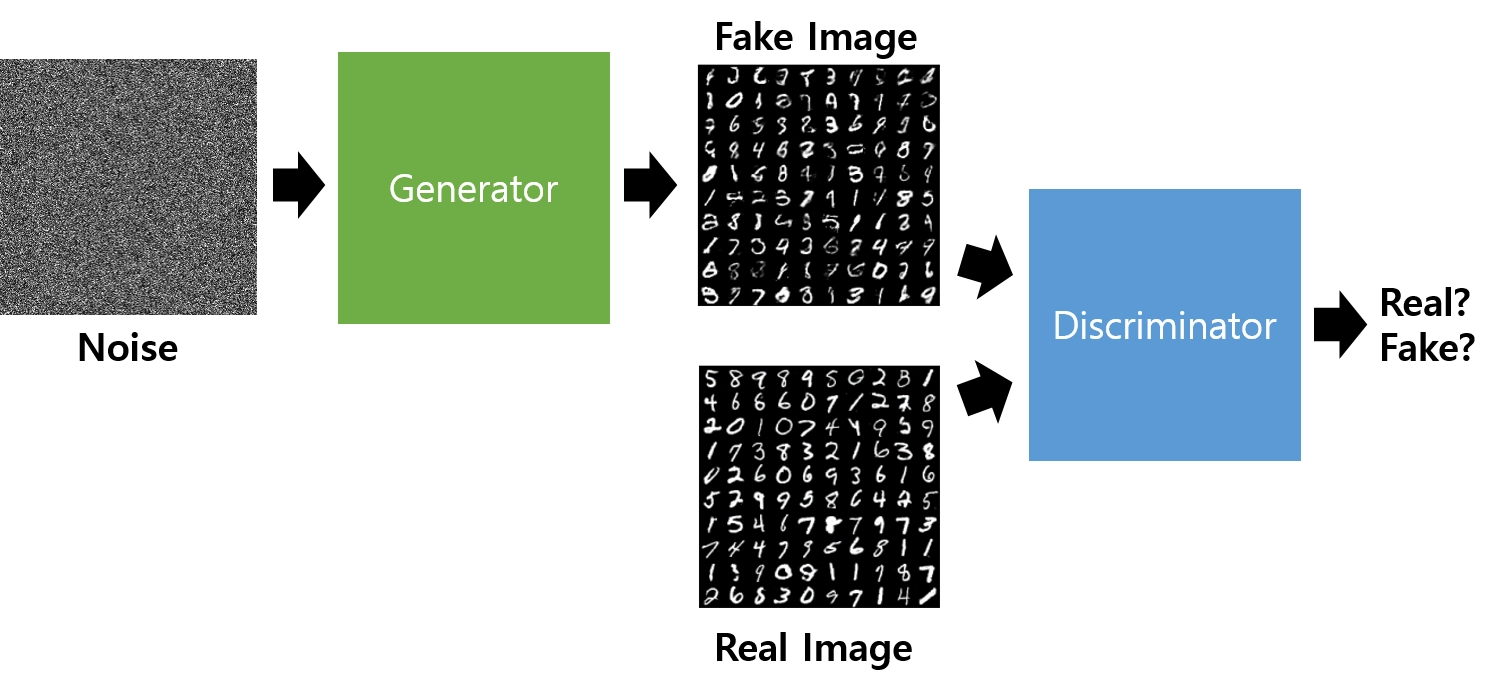  
- 생성자: 
    - 입력: 무작위 노이즈(잠재 변수 Z)를 입력받음
    - 출력: 실제 데이터와 유사한 가짜 데이터(G(Z))를 생성
    - 목표: 판별자를 속여서 가짜를 진짜(1)로 믿게 만드는 것
- 판별자:
    - 입력: 실제 데이터(X)와 생성자가 만든 가짜 데이터(G(Z))를 모두 입력받음
    - 출력: 입력 데이터가 진짜일 확률(0 ~ 1)을 출력
    - 목표: 진짜는 1로, 가짜는 0으로 정확히 분류하는 분류 모델의 역할을 수행
<br>
## 3. GAN의 장단점
- 장점:
    - 진짜 같은 가짜 생성 가능
    - 압도적인 선명도: VAE가 수학적 평균을 취하며 흐릿한(Blurry) 이미지를 만드는 것과 달리, GAN은 판별자를 통과하며 매우 선명하고 깨끗한 샘플을 생성
    - 빠른 생성 속도 : 확산 모델처럼 여러 단계를 거치지 않고, 신경망을 한 번만 통과(Direct Sampling)하면 결과물 나옴
    - 잠재 공간의 부드러움: 학습된 잠재 공간에서 두 점 사이를 이동하며 생성하면, 이미지가 부드럽게 변하는 '보간(Interpolation)'이 가능하여 데이터의 구조를 잘 이해했음을 보여줌
- 단점: 
    - 학습의 불안정성:
        - 진동 현상(Oscillation): 에폭(Epoch)이 진행될수록 손실(Loss) 값이 떨어지지 않고 위아래로 크게 요동침
        - 끝없는 숨바꼭질 (무한루프): 생성자(G)와 판별자(D)를 한 번씩 번갈아 가며 업데이트-> 이론적인 최적점에 도달하기보다는 서로를 이기기 위한 '무한 루프'에 빠지기 쉬움
    - 훈련 초기 문제: 판별자가 너무 완벽하게 가짜를 잡아낼 때 -> G가 "가짜를 진짜라고 믿게 만들 확률"을 직접적으로 높이는 방식을 사용하여 해결
    - 모드 붕괴 (Mode Collapse): 생성자가 판별자를 속이기 가장 쉬운 특정 패턴 하나만 계속 만드는 문제
    - 객관적인 평가 지표 부재
    - 역매핑 불가능
<br>
## 4. 적용 사례
- NVIDIA(2017) - 가짜 이미지 생성
- University of Washington(2017) - 가짜 오바마 연설 영상
- Facebook(2017) - Eye In-Painting

# 4. 확산 모델(Diffusion Model)

## 1. 확산 모델의 개념
- 확산 모델(Diffusion Model): 입력 이미지에 노이즈를 조금씩 추가하여 완전한 노이즈로 만든 뒤, 다시 거꾸로 복원하는 과정을 학습하여 입력 이미지와 유사한 확률 분포를 가진 결과 이미지를 생성하는 모델
- 목표: 순확산과 역확산 단계를 거쳐 생성된 '결과 이미지'의 확률 분포를 '원래 데이터'의 확률 분포와 최대한 유사하게 만드는 것
- 모호성 모델링: 모호한 요청에 대해 완전한 노이즈 상태에서 시작해 데이터 구조의 아주 작은 부분을 조금씩 '환각(=상상)'하며 구체적인 이미지를 완성해 나감
<br>
## 2. 확산 모델의 구조 : 순확산과 역확산
- **순확산**(Forward Diffusion Process): 데이터에 점진적으로 (정규분포를 가진)노이즈를 추가하는 과정
- 원본 데이터 -> 노이즈 추가 -> 완전한 무작위 노이즈
- **역확산**(Reverse Diffusion): 노이즈 데이터에서 원본 데이터를 재구성하는 과정
- 완전한 노이즈 데이터 -> 노이즈 제거 -> 이미지 복원
<br>
## 3. 확산 모델의 장단점
- 장점: 
    - 압도적인 샘플 품질: GAN보다 더 정교하고 다양한 이미지를 생성할 수 있으며, 고해상도 확장에 유리
    - 학습의 안정성: GAN과 달리 손실 곡선(Loss Curve)을 확인할 수 있음
    - 다양성 확보: GAN의 고질적인 문제인 모드 붕괴(특정 이미지만 반복 생성) 현상이 거의 나타나지 않음
- 단점:
    - 느린 생성 속도
    - 높은 계산 비용
    - 구조적 제약: 노이즈 분포 Z와 데이터 X의 형태(Shape)가 동일해야 함

# **AI 최적화**

# 1. 전이학습과 딥러닝 경량화

## 1. 전이학습
- 전이학습: 데이터나 문제 유형이 달라도 다른 상황에서 배운 지식을 가져와서 새로운 상황에서 성능을 높이는 것
    - Domain: 어떤 데이터를 다루고 있는가
    - Task: 그 데이터로 무엇을 예측하는가
    - Source: 어디서 지식을 가져오는가
    - Target: 어디에 지식을 적용하는가
    => Domain과 Task 중에 하나라도 다를 때 의미가 생김
<br>
## 2. 전이학습의 분류
- 도메인과 테스크에 따른 분류
    - 귀납적 전이학습 (Inductive TL): 소스와 타겟의 task가 다르고 타겟 도메인에 라벨이 존재할 때
    - 트랜스듀서형 전이학습 (Transductive TL): 소스와 타겟의 task는 같지만 도메인이 다를 때
    - 비지도 전이학습 (Unsupervised TL): 소스와 타겟의 task가 다르고 소스와 타겟 모두 라벨이 없을 때
- 무엇을 전이하느냐에 따른 분류
    - 인스턴스(Instance): 소스 데이터 중 타겟에 도움이 될만한 샘플을 골라 가중치를 부여(데이터 레벨의 전이)
    - 특징(Feature): 소스와 타겟의 공통적인 특징을 추출할 수 있는 '표현 방식'을 전이(표현 레벨의 전이)
    - 파라미터(Parameter): 모델의 가중치(𝑊)나 하이퍼파라미터 초기값을 그대로 가져옴
    - 관계(Relation): 데이터 간의 논리적 관계나 구조적 지식을 전이
<br>
## 3. Pre-training & Fine-tuning
- 트랜스포머 이후의 전이학습: 전 학습된 거대 모델 (Pre-trained Model) 들이 등장하기 시작
    - Foundation Model(파운데이션 모델): 방대한 양의 비정형, 레이블이 없는 데이터로 비지도 학습을 통해 훈련된 거대한 AI 모델
    - Fine-tuning: 파운데이션 모델을 가져왔으면, 용도에 맞게 조정해야 함

    | 구분     | 데이터 적음          | 데이터 충분              |
    | ------ | --------------- | ------------------- |
    | 도메인 유사 | Frozen Backbone | Partial Fine-tuning |
    | 도메인 다름 | 처음부터 훈련 고려      | Full Fine-tuning    |

- PEFT(Parameter-Efficient Fine-Tuning): 작은 보정값만 더해서 최종 판단인 결과를 바꾸는 방식
- Zero-shot Transfer: 학습 데이터가 없어도, 언어 이해 능력만을 기반으로 바로 추론을 수행
- Few-shot Transfer(In-Context Learning): 극소수의 예시만으로 새로운 태스크를 수행하는 것
- 전이학습의 한계:
    - Negative Transfer: Source와 Target의 도메인이 너무 다르면 오히려 전이가 성능을 떨어트림
    - Catastrophic Forgetting: Fine-tuning 과정에서 새 데이터에 너무 치우치면, 모델이 원래 가지고 있던 일반 능력을 잃어버림
    - Bias Transfer: 사전 학습 데이터에 담긴 편향이 그대로 넘어오게 되는 것
    - Transferability 측정의 어려움: 어떤 두 Task가 얼마나 관련되어 있는지를 사전에 정량적으로 측정하기 어려움
- 딥러닝 경량화: 
    - 가지치기: 모델의 파라미터 중 중요도가 낮은(영향력이 적은) 가중치를 제거하여 모델의 크기를 줄이고, 연산 속도를 높이는 기법
    - 양자화: 모델의 가중치를 표현하는 숫자의 정밀도를 줄이는 방법
    - 지식 증류: 크고 복잡한 미리 학습된 모델(Teacher Model)의 지식을 작고 가벼운 모델(Student Model)에게 전달하는 방식
    - 모델 구조 경량화 (Model Architecture Optimization)
    - 하드웨어 가속화 (Hardware Acceleration)

# 2. AI Alignment

## 1. AI Alignment
- AI Alignment(인공지능 정렬): AI가 인간의 의도(Intent), 목표(Goal), 그리고 윤리적 가치(Values)에 부합하도록 행동하도록 하는 것
- Outer Alignment: "목표를 제대로 설정했는가?"
-  Inner Alignment: "모델이 내면에서 무엇을 최적화하는가?"
- 정렬을 어렵게 만드는 요인들:
    - 가치 정렬의 모호성 (Value Alignment Problem)
    - 확장 가능한 감독 (Scalable Oversight)
<br>
## 2. RLHF
- RLHF(Reinforcement Learning from Human Feedback): 인간의 피드백을 기반으로 모델을 강화학습으로 조정하는 방법
    1. 지도 미세 조정 (Supervised Fine-Tuning, SFT): 사전 학습된 모델(Pre-trained Model)이 인간의 지시(Instruction)를 따르는 방법을 배우는 과정
    2. 보상 모델 학습 (Reward Model, RM): 인간의 선호도에 따라 점수를 매기는 '채점기'를 만드는 단계
    3. 강화 학습 (Reinforcement Learning, RL): 보상 모델을 기준으로 언어 모델의 성능을 극대화하는 최종 최적화 단계

# 3. 프롬프트 엔지니어링
- 프롬프트 엔지니어링: AI가 더 좋은 답변을 내도록 입력을 설계하는 기술
- 주요 기법:
    - Zero-shot / Few-shot Prompting: 예시 없음/예시 몇 가지
    - Chain-of-Thought (CoT): 풀이 과정을 단계별로 생각하게 만드는 기법
    - Role Prompting — 역할 부여
    - Instruction Prompting — 명확한 지시
    - Self-Consistency — 여러 번 물어보기
    - RAG (Retrieval-Augmented Generation) — 검색 증강 생성
- 한계: 
    - Prompt Injection — 프롬프트 주입 공격
    - Hallucination — 그럴듯한 거짓말
    - 모델 의존성: 같은 프롬프트여도 모델마다 효과가 다를 수 있음
    - 성능 한계: Fine-tuning 수준의 성능을 내기 어려운 경우 있음